In [8]:
%load_ext autoreload
%autoreload 2

import os
import sys
module_path = os.path.abspath(os.path.join('../..'))
if module_path not in sys.path:
    sys.path.append(module_path)

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd
import jax
import seaborn as sns

jax.config.update('jax_platforms', 'cpu')

plt.rcParams['font.family'] = 'Helvetica Light'

from behavioral_plotting import (
    plot_session,
    load_odor_site_df,
    plot_patch_statistics_per_session,
    plot_patch_statistics,
    plot_multi_df_accuracy_heatmap,
    plot_leave_probabilities,
    append_index_phase,
    plot_grouped_mean_std,
    plot_stop_fraction,
    odor_colors,
)
from aux_funcs import format_plot
from nb_analysis_tools import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [9]:
# had to clear the font cache to get the Helvetica Light font to work.
# If you see a warning about missing fonts, run this cell and restart the kernel.

# import matplotlib as mpl
# import shutil, os

# # Find and delete the font cache
# cache_dir = mpl.get_cachedir()
# print(f"Cache dir: {cache_dir}")

# # Delete cache files
# for f in os.listdir(cache_dir):
#     if f.endswith('.json') or f.endswith('.cache'):
#         os.remove(os.path.join(cache_dir, f))
#         print(f"Deleted: {f}")

# print("Done — restart the kernel now")

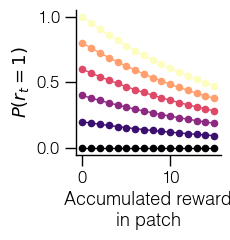

In [10]:
# ── Exponential decay curves ──────────────────────────────────────────────
prefactors  = [0,  0.2, 0.4, 0.6, 0.8, 1]   # one per curve
decay_rates = [1/20] * 6   # one per curve

x = np.arange(16)   # 0 through 20

fig, ax = plt.subplots(figsize=(2.5, 2.5))
for prefactor, decay_rate in zip(prefactors, decay_rates):
    color = mpl.colormaps['magma'](prefactors.index(prefactor) / (len(prefactors) - 1))
    y = prefactor * np.exp(-decay_rate * x)
    ax.plot(x, y, color=color, lw=1)
    ax.scatter(x, y, color=color, s=20)
ax.set_xlabel('Accumulated reward\nin patch')
ax.set_ylabel(r'$P(r_t=1)$')
format_plot(ax)
plt.tight_layout()
plt.show()

In [11]:
FIXED_EXP_GRU_INITIAL_PROB_OFFSET_NETWORKS = [
    '../../../results/indep_exp_gru_initial_prob_offset_net0/trajectories_20260602_125704.pkl',
]

FIXED_EXP_GRU_INITIAL_PROB_OFFSET_NETWORKS_GRR = [
    '../../../results/indep_exp_gru_initial_prob_offset_global_reward_mean_10_256_unit/trajectories_20260604_123117.pkl',
]

[0.04675114 0.4637537  0.6249846 ]


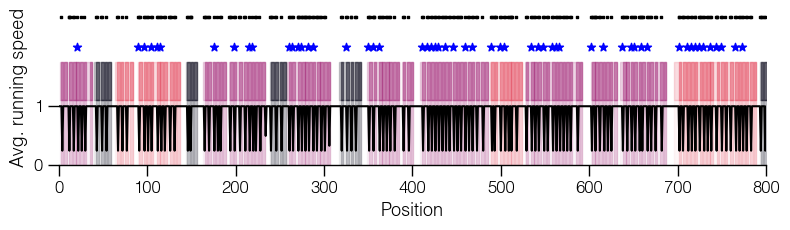

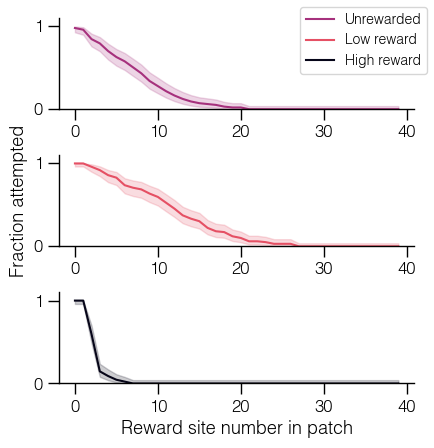

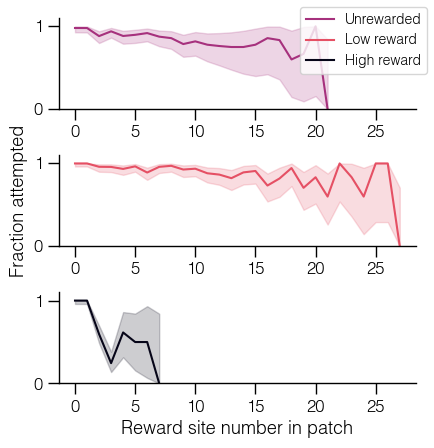

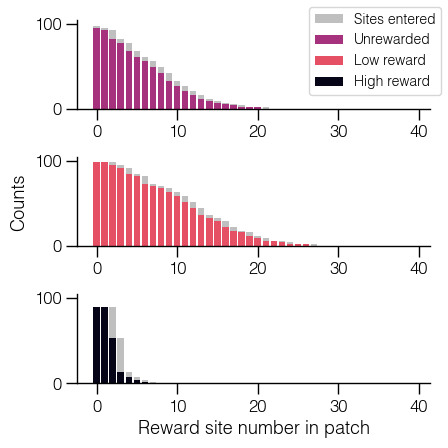

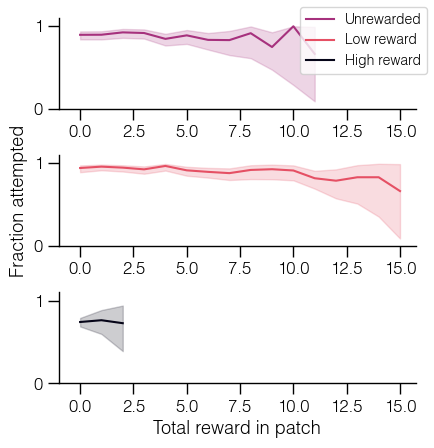

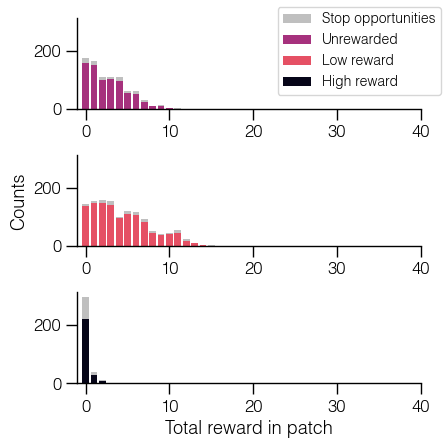

In [ ]:
for i, data_path in enumerate(FIXED_EXP_GRU_INITIAL_PROB_OFFSET_NETWORKS):
    plot_session(
        data_path,
        session_idx=1,
        xlim=(0, 800),
        max_reward_param=40,
        max_reward_sites=30,
        use_fixed_colors=False,
        color_by_reward_param=False
    )

In [6]:
dfs = [
    load_odor_site_df(x, nn_num=nn_num)
    for nn_num, x in enumerate(FIXED_EXP_GRU_INITIAL_PROB_OFFSET_NETWORKS)
]

Session data loaded
Session summaries generated


In [87]:
dfs_grr = [
    load_odor_site_df(x, nn_num=nn_num)
    for nn_num, x in enumerate(FIXED_EXP_GRU_INITIAL_PROB_OFFSET_NETWORKS_GRR)
]

Session data loaded
Session summaries generated


<string>:37: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.


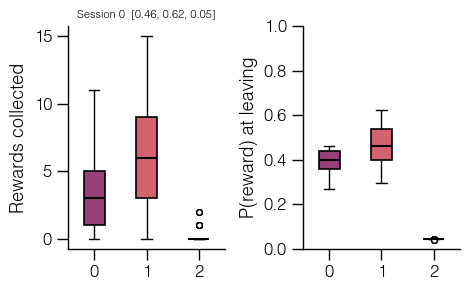

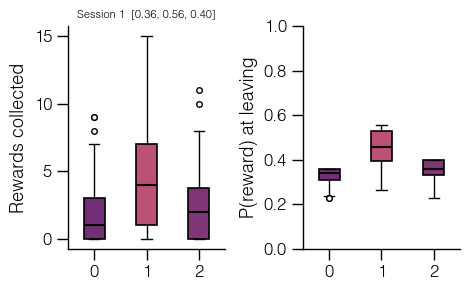

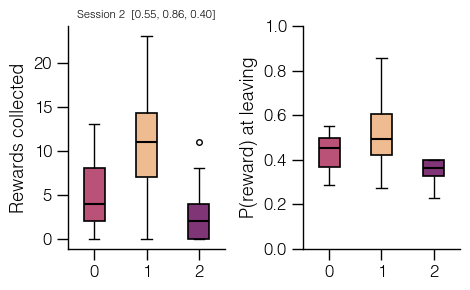

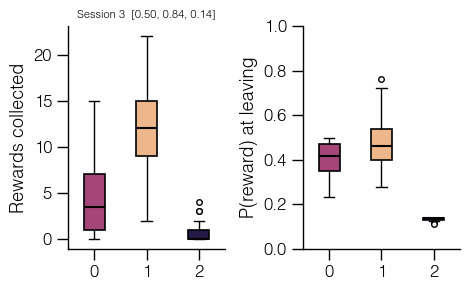

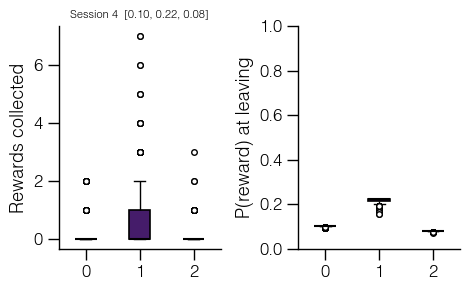

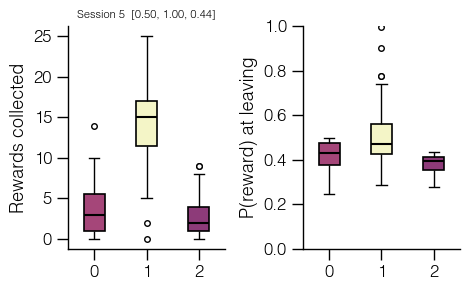

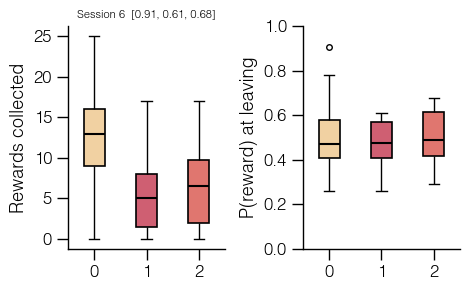

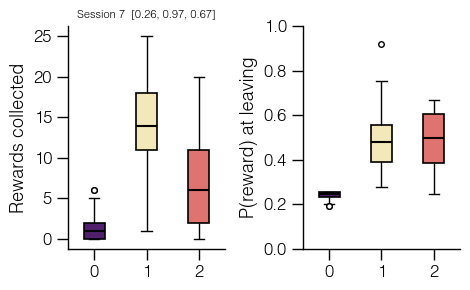

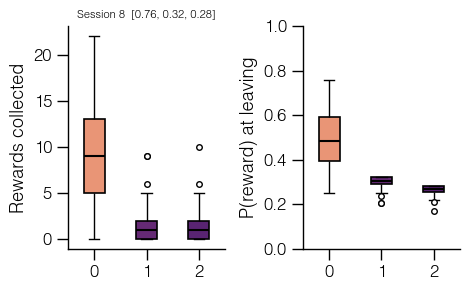

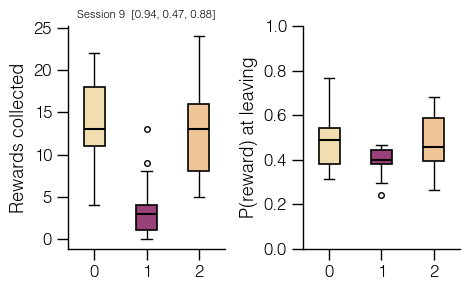

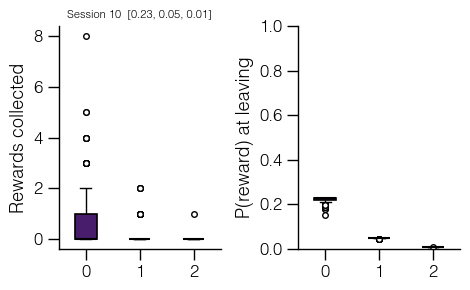

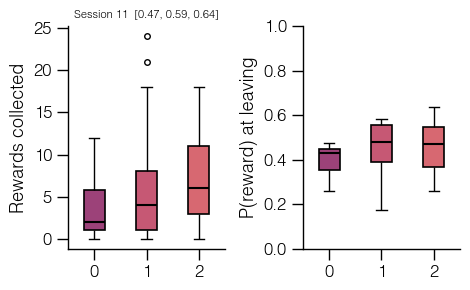

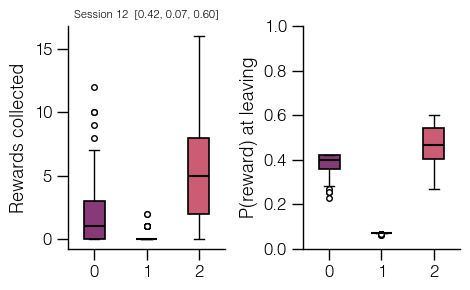

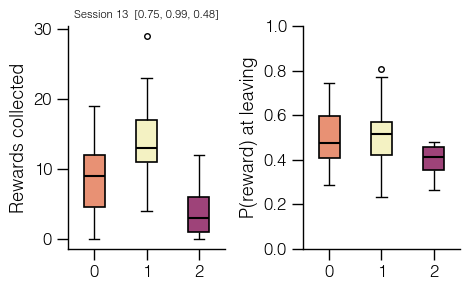

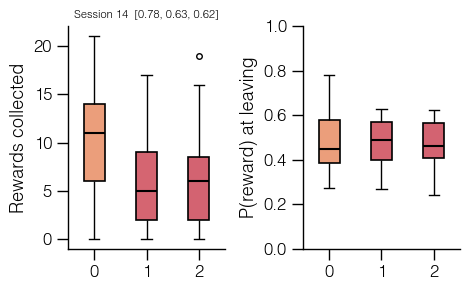

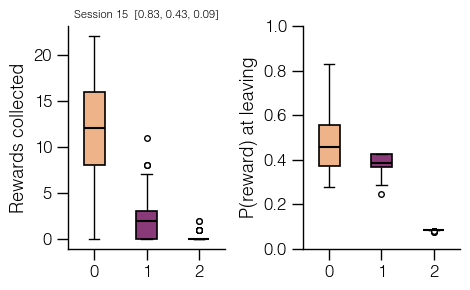

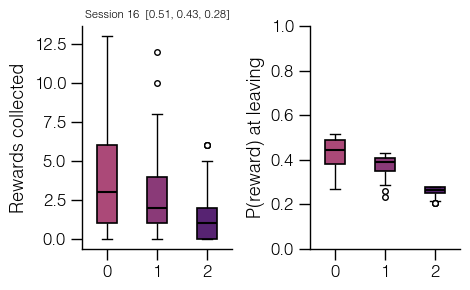

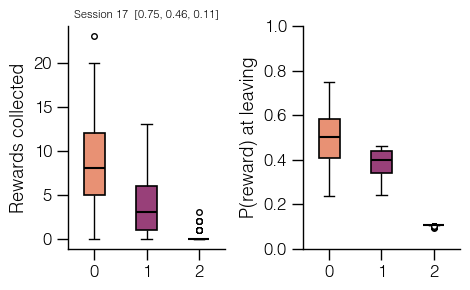

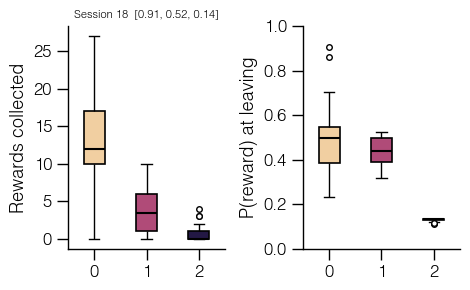

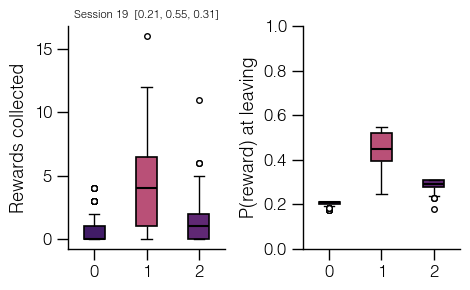

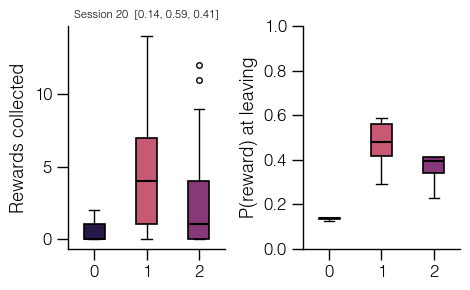

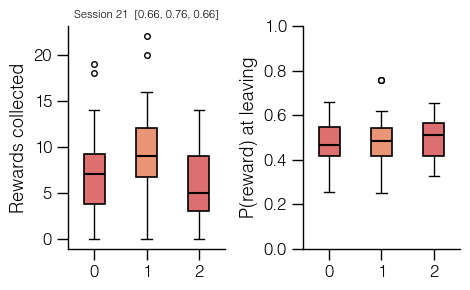

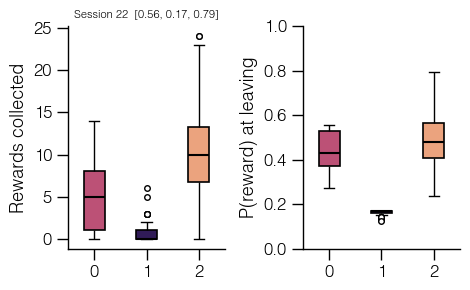

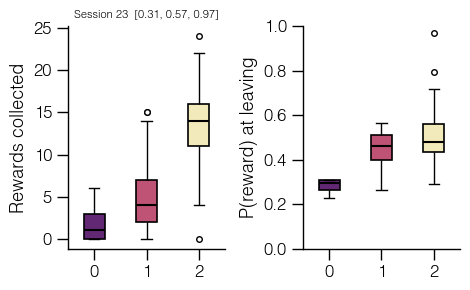

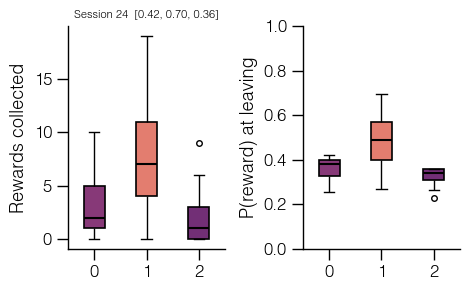

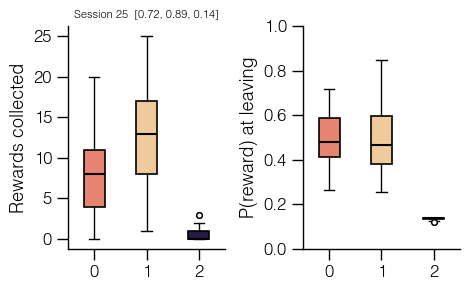

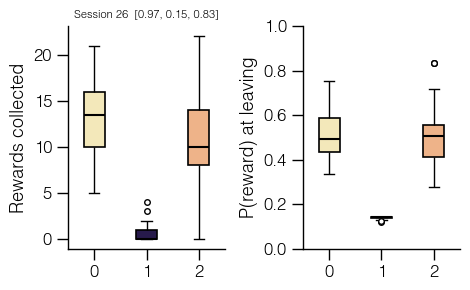

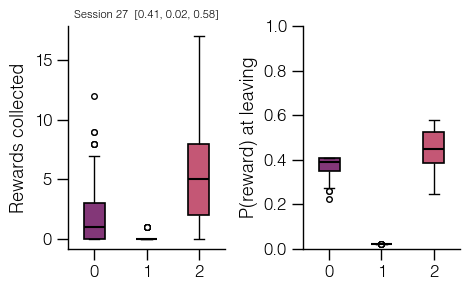

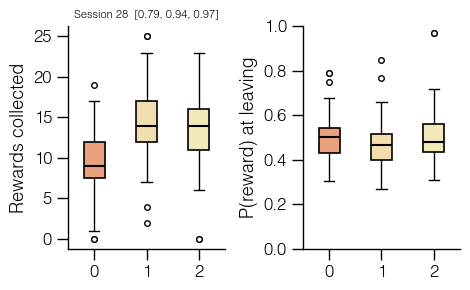

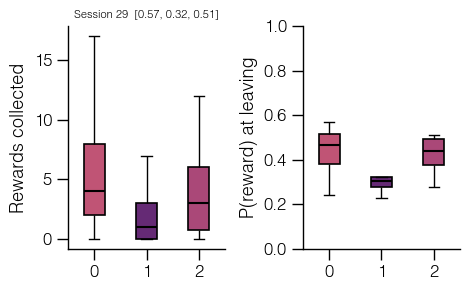

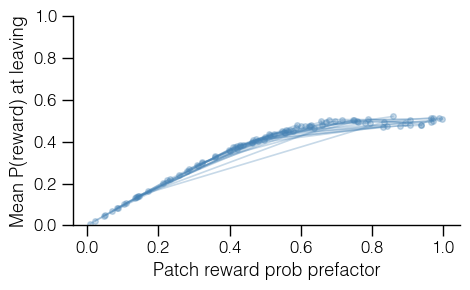

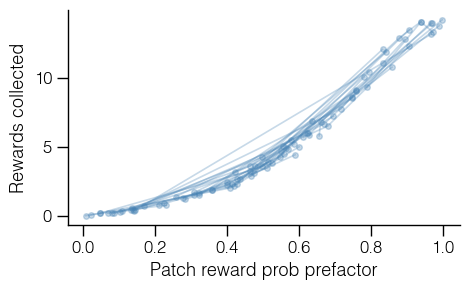

In [91]:
for df in dfs:
    plot_patch_statistics_per_session(
        df,
        ylim_right=[0, 1.],
    )

In [7]:
for df in dfs_grr:
    plot_patch_statistics_per_session(
        df,
        ylim_right=[0, 1.],
    )

NameError: name 'dfs_grr' is not defined

Processing GRU (offset)...


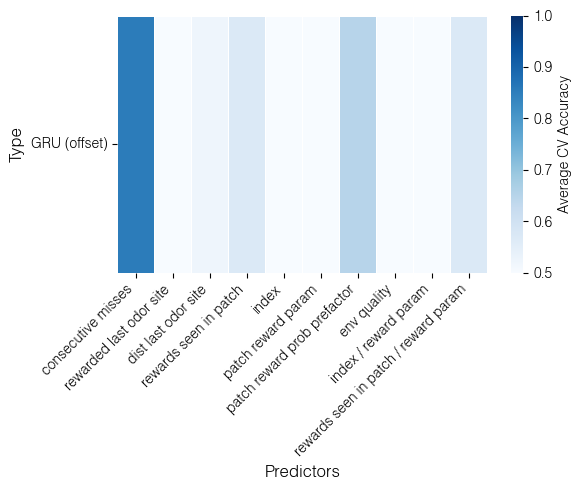

In [67]:
plot_multi_df_accuracy_heatmap(
    [df[df['index'] > 0] for df in dfs],
    [
        'consecutive_misses',
        'rewarded_last_odor_site',
        'dist_last_odor_site',
        'rewards_seen_in_patch',
        'index',
        'patch_reward_param',
        'patch_reward_prob_prefactor',
        'env_quality',
        'index / reward_param',
        'rewards_seen_in_patch / reward_param',
    ],
    df_labels=['GRU (offset)'] * len(dfs),
    figsize=(6, 5),
)

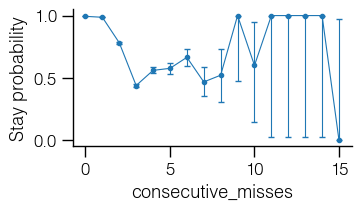

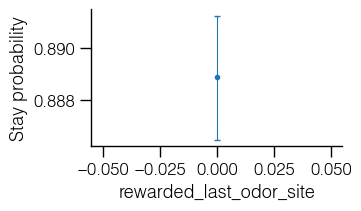

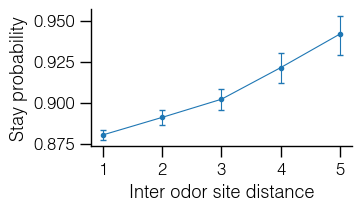

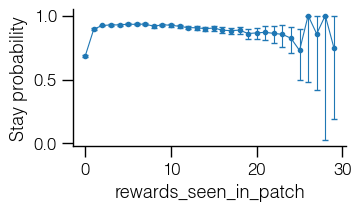

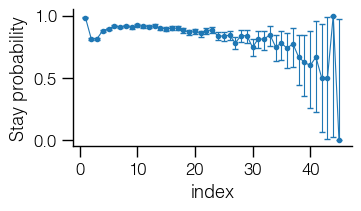

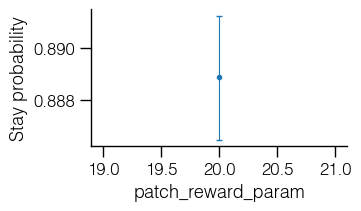

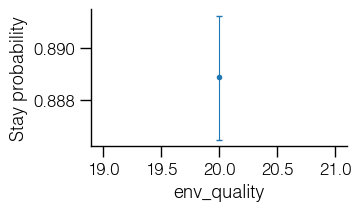

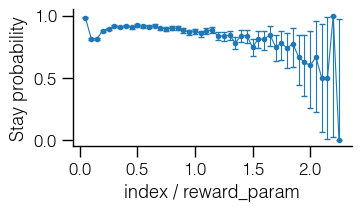

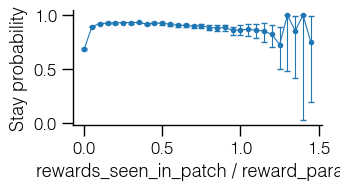

In [64]:
plot_leave_probabilities(
    [df[(df['index'] > 0)] for df in dfs],
    [
        'consecutive_misses',
        'rewarded_last_odor_site',
        'dist_last_odor_site',
        'rewards_seen_in_patch',
        'index',
        'patch_reward_param',
        'env_quality',
        'index / reward_param',
        'rewards_seen_in_patch / reward_param',
    ],
    x_labels=[
        'consecutive_misses',
        'rewarded_last_odor_site',
        'Inter odor site distance',
        'rewards_seen_in_patch',
        'index',
        'patch_reward_param',
        'env_quality',
        'index / reward_param',
        'rewards_seen_in_patch / reward_param',
    ],
)

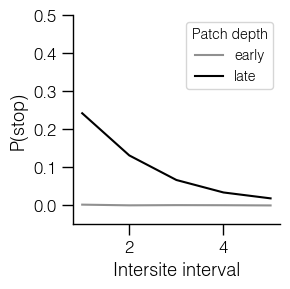

In [29]:
fig = plot_grouped_mean_std(
    append_index_phase(pd.concat([df[df['index'] > 0] for df in dfs])),
    'dist_last_odor_site',
    'segment',
    'stopped',
    'network_num',
)
# savefig(fig, '../../figures/offset_intersite_interval_early_late')

In [ ]:
dfs[0].columns

Index(['dist_last_odor_site', 'patch_reward_param', 'index', 'stopped',
       'rewarded', 'rewarded_last_odor_site', 'added', 'rewards_seen_in_patch',
       'global_reward_rate_param', 'patch_number', 'session_number',
       'consecutive_misses', 'rewarded_1', 'rewarded_2', 'rewarded_3',
       'rewarded_4', 'rewarded_5', 'rewarded_6', 'rewarded_7', 'rewarded_8',
       'rewarded_9', 'rewarded_10', 'rewarded_11', 'rewarded_12',
       'rewarded_13', 'rewarded_14', 'rewarded_15', 'rewarded_16',
       'rewarded_17', 'rewarded_18', 'rewarded_19', 'rewarded_20',
       'rewarded_21', 'rewarded_22', 'rewarded_23', 'rewarded_24',
       'rewarded_25', 'rewarded_26', 'rewarded_27', 'rewarded_28',
       'rewarded_29', 'rewarded_30', 'rewarded_31', 'rewarded_32',
       'rewarded_33', 'rewarded_34', 'rewarded_35', 'rewarded_36',
       'rewarded_37', 'rewarded_38', 'rewarded_39', 'rewarded_40',
       'rewarded_41', 'rewarded_42', 'rewarded_43', 'rewarded_44',
       'rewarded_45', 'reward

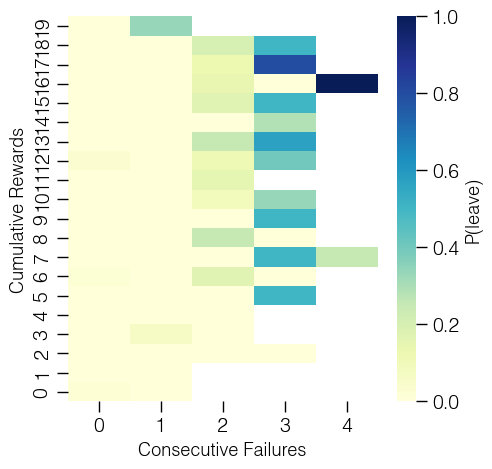

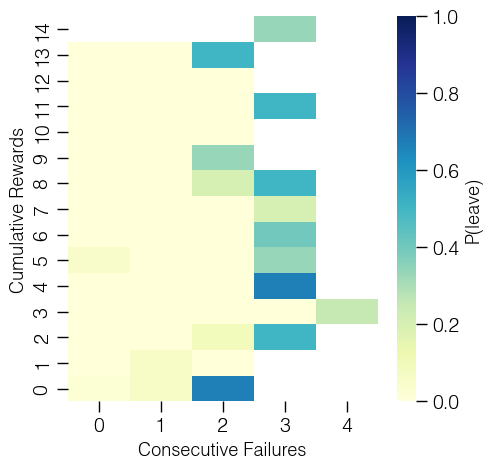

In [66]:
for df in dfs:
    plot_stop_fraction(
        df,
        'consecutive_misses',
        'rewards_seen_in_patch',
        condition=lambda x: (x[(x['patch_type'] == 0) & (x['session_number'] == 6)]),
        invert_y=True,
        figsize=(5, 5),
        reverse=True,
        xlabel='Consecutive Failures',
        ylabel='Cumulative Rewards',
        min_n=3,
    )
    plot_stop_fraction(
        df,
        'consecutive_misses',
        'rewards_seen_in_patch',
        condition=lambda x: (x[(x['patch_type'] == 2) & (x['session_number'] == 6)]),
        invert_y=True,
        figsize=(5, 5),
        reverse=True,
        xlabel='Consecutive Failures',
        ylabel='Cumulative Rewards',
        min_n=3,
    )
None

In [1]:
for df in dfs:
    plot_stop_fraction(
        df,
        'consecutive_misses',
        'rewards_seen_in_patch',
        invert_y=True,
        figsize=(5, 5),
        reverse=True,
        xlabel='Consecutive Failures',
        ylabel='Cumulative Rewards',
        min_n=3,
    )
None

NameError: name 'dfs' is not defined

In [ ]:
dfs[0].columns

Index(['dist_last_odor_site', 'patch_reward_param', 'index', 'stopped',
       'rewarded', 'rewarded_last_odor_site', 'added', 'rewards_seen_in_patch',
       'global_reward_rate_param', 'patch_number', 'session_number',
       'consecutive_misses', 'rewarded_1', 'rewarded_2', 'rewarded_3',
       'rewarded_4', 'rewarded_5', 'rewarded_6', 'rewarded_7', 'rewarded_8',
       'rewarded_9', 'rewarded_10', 'rewarded_11', 'rewarded_12',
       'rewarded_13', 'rewarded_14', 'rewarded_15', 'rewarded_16',
       'rewarded_17', 'rewarded_18', 'rewarded_19', 'rewarded_20',
       'rewarded_21', 'rewarded_22', 'rewarded_23', 'rewarded_24',
       'rewarded_25', 'rewarded_26', 'rewarded_27', 'rewarded_28',
       'rewarded_29', 'rewarded_30', 'rewarded_31', 'rewarded_32',
       'rewarded_33', 'rewarded_34', 'rewarded_35', 'rewarded_36',
       'rewarded_37', 'rewarded_38', 'rewarded_39', 'rewarded_40',
       'rewarded_41', 'rewarded_42', 'rewarded_43', 'rewarded_44',
       'rewarded_45', 'reward

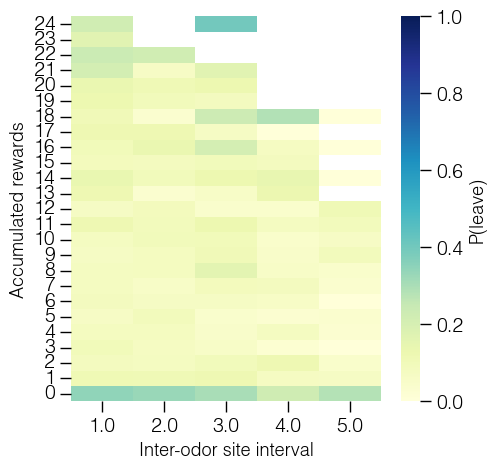

In [54]:
for df in dfs:
    plot_stop_fraction(
        df,
        'dist_last_odor_site',
        'rewards_seen_in_patch',
        condition=lambda x: x[x['patch_type'] == 2],
        invert_y=True,
        figsize=(5, 5),
        reverse=True,
        xlabel='Inter-odor site interval',
        ylabel='Accumulated rewards',
        min_n=5,
    )
None

In [17]:
print(dfs[0].columns)

Index(['dist_last_odor_site', 'patch_reward_param', 'index', 'stopped',
       'rewarded', 'rewarded_last_odor_site', 'added', 'rewards_seen_in_patch',
       'global_reward_rate_param', 'patch_number', 'session_number',
       'patch_type', 'consecutive_misses', 'rewarded_1', 'rewarded_2',
       'rewarded_3', 'rewarded_4', 'rewarded_5', 'rewarded_6', 'rewarded_7',
       'rewarded_8', 'rewarded_9', 'rewarded_10', 'rewarded_11', 'rewarded_12',
       'rewarded_13', 'rewarded_14', 'rewarded_15', 'rewarded_16',
       'rewarded_17', 'rewarded_18', 'rewarded_19', 'rewarded_20',
       'rewarded_21', 'rewarded_22', 'rewarded_23', 'rewarded_24',
       'rewarded_25', 'rewarded_26', 'rewarded_27', 'rewarded_28',
       'rewarded_29', 'rewarded_30', 'rewarded_31', 'rewarded_32',
       'rewarded_33', 'rewarded_34', 'rewarded_35', 'rewarded_36',
       'rewarded_37', 'rewarded_38', 'rewarded_39', 'rewarded_40',
       'rewarded_41', 'rewarded_42', 'rewarded_43', 'rewarded_44',
       'rewarde

Index(['dist_last_odor_site', 'patch_reward_param',
       'patch_reward_prob_prefactor', 'index', 'stopped', 'rewarded',
       'rewarded_last_odor_site', 'added', 'rewards_seen_in_patch',
       'global_reward_rate_param', 'patch_number', 'session_number',
       'patch_type', 'consecutive_misses', 'rewarded_1', 'rewarded_2',
       'rewarded_3', 'rewarded_4', 'rewarded_5', 'rewarded_6', 'rewarded_7',
       'rewarded_8', 'rewarded_9', 'rewarded_10', 'rewarded_11', 'rewarded_12',
       'rewarded_13', 'rewarded_14', 'rewarded_15', 'rewarded_16',
       'rewarded_17', 'rewarded_18', 'rewarded_19', 'rewarded_20',
       'rewarded_21', 'rewarded_22', 'rewarded_23', 'rewarded_24',
       'rewarded_25', 'rewarded_26', 'rewarded_27', 'env_quality',
       'rewarded_28', 'rewarded_29', 'rewarded_30', 'rewarded_31',
       'rewarded_32', 'rewarded_33', 'rewarded_34', 'rewarded_35',
       'rewarded_36', 'rewarded_37', 'rewarded_38', 'rewarded_39',
       'rewarded_40', 'rewarded_41', 'reward

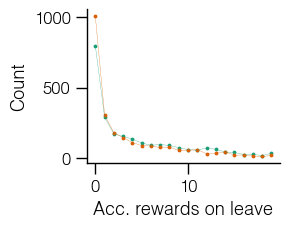

In [69]:
patch_nums = [1, 2]
colors = odor_colors[1:]
fig, axs = plt.subplots(1, 1, figsize=(2.5, 2))

print(dfs[0].columns)

all_stds = []
for df in dfs:
    stds_for_df = []
    for pn, c in zip(patch_nums, colors):
        opt_out_sites = df[(df['stopped'] == 0) & (df['patch_type'] == pn)]
        mu_zero = (opt_out_sites['rewards_seen_in_patch'] - opt_out_sites['rewards_seen_in_patch'].mean())
        std = mu_zero.std()
        stds_for_df.append(std)
        vals, bins = np.histogram(opt_out_sites['rewards_seen_in_patch'], bins=np.arange(21))
        axs.plot(bins[:-1], vals, color=c, alpha=1, lw=0.2)
        axs.scatter(bins[:-1], vals, color=c, s=3)
    all_stds.append(stds_for_df)
axs.set_xlabel('Acc. rewards on leave')
axs.set_ylabel('Count')
group_stds = np.array(all_stds)
print(group_stds)
print(group_stds.mean(axis=0))
print(group_stds.std(axis=0))
# axs.text(15, 1000, (
#     rf'Low patch $\sigma$ = {group_stds.mean(axis=0)[0]:.1f} $\pm$ {group_stds.std(axis=0)[0]:.1f}' + '\n'
#     + rf'High patch $\sigma$ = {group_stds.mean(axis=0)[1]:.1f} $\pm$ {group_stds.std(axis=0)[1]:.1f}'
# ))
format_plot(axs)
